In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import scipy.io as io
import sys

global_path = "/home/ids/edabier/HSU"
# global_path = "/home/edabier/Documents/Thèse/benchmark"
sys.path.append(f"{global_path}/HyperSIGMA/HyperspectralUnmixing")
from mmengine.optim import build_optim_wrapper
from mmcv__custom import custom_layer_decay_optimizer_constructor

import src.utils.utils as utils
import src.utils.losses as losses
import src.utils.plots as plots
import src.utils.extractor as extractor
import src.models.models as models
import src.models.foundation_models as rsfm
import src.models.srvit as srvit

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
    
elif torch.backends.mps.is_available():
    dev = torch.device("mps")
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
  
else:
    dev = "cpu"
    print(f"Using device: {dev}")

/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttri

Using device: cuda:0


In [15]:
dataset = "samson"
data = io.loadmat(f"datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float)
A_flat = torch.tensor(data["A"], dtype=torch.float)
E_init = torch.tensor(data["E"], dtype=torch.float)
B, c, N = E_init.shape[0], E_init.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat)
A_init = utils.oneD_to_2d(A_flat)
H = Y_init.shape[-1]
Y_init = Y_init.unsqueeze(0)
A_init = A_init.unsqueeze(0)

if dataset == "urban4":
    with open(f"{global_path}/SS-HSU_benchmark/datasets/urban_wavelength.txt", "r") as file:
        lines = file.readlines()
        wavelengths = [float(line.strip()) for line in lines if line.strip()]

else:
    with open(f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt", "r") as file:
        lines = file.readlines()
        wavelengths = [float(line.strip()) for line in lines if line.strip()]

In [16]:
n_features = 1
fm, Y_init_f, new_H = rsfm.create_fm("DOFA", Y_init, n_features=n_features, use_cls=False, extend_cls=False, path=global_path, patch_size=16)
features = rsfm.get_dofa_features(fm, Y_init_f, wavelengths)
# features = rsfm.get_hyperfree_features(fm, Y_init_f, wavelengths)
D = int(features.shape[0]/1)

print(f"features: {features.shape}")

alpha = int(features.shape[1]**0.5)
unmixer = rsfm.Unmixing_from_features(D=D, alpha=alpha, B=B, c=c, n_features=n_features, use_cls=False)

features: torch.Size([768, 196])


{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
First sad: 0.104


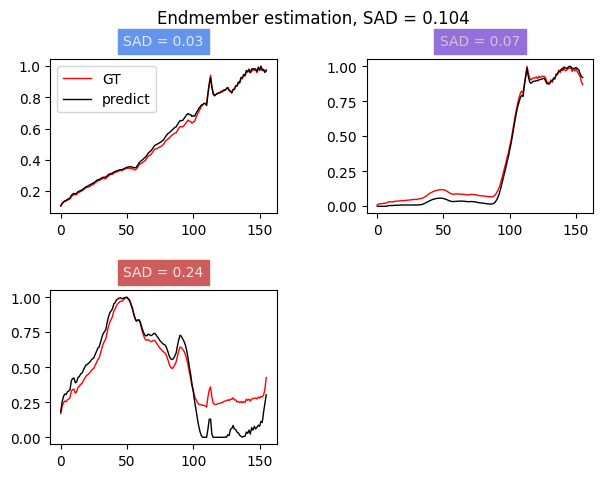

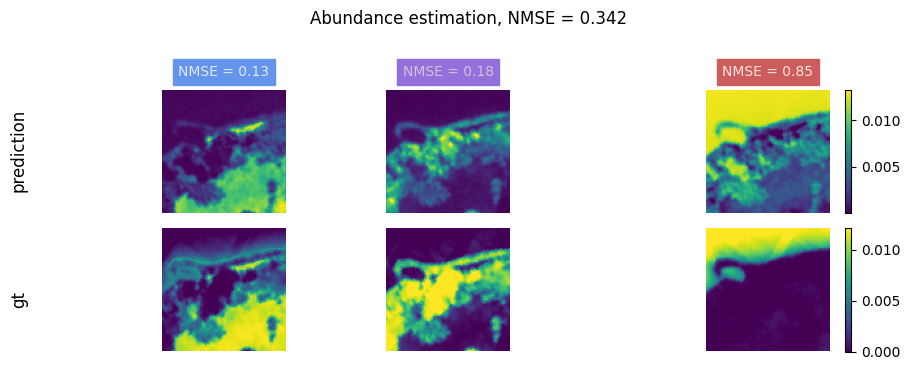

In [17]:
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)

epochs, lr = 200, 0.002

optim_wrapper = dict(
    optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
    constructor='LayerDecayOptimizerConstructor_ViT',
    paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9))

patch, dim = 10, 24
inner_patch, inner_dim = 5, 24
model = models.SRViT(B=B, c=c, H=H, patch=patch, dim=dim, inner_patch=inner_patch, inner_dim=inner_dim).to(dev)
model.apply(model.weights_init)
model = models.init_decoder_weights(model, Y_init/Y_init.max(), c)
# model.embedder.model = models.init_decoder_weights(model.embedder.model, Y_init/Y_init.max(), c, model_name="SRViT")
optimizer = build_optim_wrapper(model, optim_wrapper)

for epoch in range(epochs):
    
    for Y, E, A in loader:
        optimizer.zero_grad()

        Y = utils.oneD_to_2d(Y).to(dev)
        A = utils.oneD_to_2d(A).to(dev)
        E = E.to(dev)

        Y_hat, _, _ = model(Y)
        loss = model.loss(Y_gt=Y, Y_hat=Y_hat)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
        optimizer.step()
        
        if hasattr(model, 'decoder'):
            with torch.no_grad():
                constraints = models.weightConstraint()
                model.decoder.apply(constraints)
        break
    
model.eval()

with torch.no_grad():
    _, E_hat1, A_hat1 = model(Y_init)
    A_hat1 = (A_hat1/torch.sum(A_hat1, dim=1)).squeeze(0).detach().cpu().numpy()

sad, sad_a, mse = plots.compute_metrics_and_plot(torch.tensor(E_hat1), torch.tensor(A_hat1), A_init, E, normalize_E=True, normalize_A=True, return_results=True)
print(f"First sad: {format(sad, '.3f')}")

In [18]:
# loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)

# epochs, lr = 1, 0.002

# optim_wrapper = dict(
#     optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
#     constructor='LayerDecayOptimizerConstructor_ViT',
#     paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9))

# patch, dim = 10, 64
# model = models.SRViT(col=H, c=c, B=B, size=H, patch=patch, dim=dim, inner_dim=dim)
# # model.embedder.model = models.init_decoder_weights(model.embedder.model, Y_init/Y_init.max(), c, model_name="SRViT")
# model = model.to(dev)
# optimizer = build_optim_wrapper(model, optim_wrapper)

# for epoch in range(epochs):
    
#     for Y, E, A in loader:
#         optimizer.zero_grad()

#         Y = utils.oneD_to_2d(Y).to(dev)
#         A = utils.oneD_to_2d(A).to(dev)
#         E = E.to(dev)

#         _, Y_hat, _ = model(Y)
#         loss = model.loss(Y_gt=Y, Y_hat=Y_hat)

#         loss.backward()
#         nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
#         optimizer.step()
        
#         if hasattr(model, 'decoder'):
#             with torch.no_grad():
#                 constraints = models.weightConstraint()
#                 model.decoder.apply(constraints)
#         break
    
# model.eval()

# with torch.no_grad():
#     A_hat1, Y_hat1, _, E_hat1 = model(Y_init)
#     A_hat1 = (A_hat1/torch.sum(A_hat1, dim=1)).squeeze(0).permute(1, 2, 0).detach().cpu().numpy()

# sad, sad_a, mse = plots.compute_metrics_and_plot(torch.tensor(E_hat1), torch.tensor(A_hat1), A_init, E, normalize_E=True, normalize_A=True, return_results=True)
# print(f"First sad: {format(sad, '.3f')}")

### Unmixer vs CNNAEU

In [6]:
# model_type = "FM"

# if model_type == "DeepTrans":
#     im_size = (H//5)*5
#     Y_init = Y_init[:,:,:im_size, :im_size]
#     A_init = A_init[:,:,:im_size, :im_size]
#     Y_init_flat = Y_init.flatten(2)
#     new_H = im_size
#     loader, _, _ = utils.create_dataloader(dataset, dev=dev, patch_size=im_size)

# else:
#     loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)

# epochs, lr = 200, 0.002
# # epochs, lr = 320, 0.0003

# optim_wrapper = dict(
#     optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),#0.05),
#     constructor='LayerDecayOptimizerConstructor_ViT',
#     paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9))

# n_xp = 10
# sads, sads_a, mses = [], [], []

# if model_type == "FM":
#     E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)

# elif model_type == "DeepTrans":
#     E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, im_size, im_size)

# else:
#     E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, H, H)

# for n in range(n_xp):

#     if model_type == "CNN_FM":
#         model = rsfm.CNNAEU_with_decoder(B, c, freeze_E=False)
#         model = models.init_decoder_weights(model, Y_init/Y_init.max(), c, is_unmixer=True, normalize=False)
    
#     elif "CNN" in model_type:
#         model = models.CNNAEU(B, c)

#         if model_type == "CNN_init":
#             model.apply(model.weights_init)
#             model = models.init_decoder_weights(model, Y_init/Y_init.max(), c, kernel=11)

#     elif model_type == "DeepTrans":
#         model = models.DeepTrans(B, c, im_size, embed_dim=200)
#         model.apply(model.weights_init)
#         model = models.init_decoder_weights(model, Y_init, c)

#     elif model_type == "UnDIP":
#         model = models.UnDIP(B, c)

#     else:
#         model = rsfm.Unmixing_from_features(D=D, alpha=alpha, H=new_H, B=B, c=c, n_features=n_features, use_cls=False, is_cnnaeu=False)
#         model.apply(model.weights_init)
#         model = models.init_decoder_weights(model, Y_init/Y_init.max(), c, is_unmixer=True, normalize=False)#, is_cnnaeu=False)

#     model = model.to(dev)
#     optimizer = build_optim_wrapper(model, optim_wrapper)
#     # optimizer = torch.optim.RMSprop(model.parameters(), lr=lr)
#     # optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=7e-3)
#     # scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.8)

#     for epoch in range(epochs):
        
#         for Y, E, A in loader:
#             optimizer.zero_grad()

#             Y = utils.oneD_to_2d(Y).to(dev)
#             A = utils.oneD_to_2d(A).to(dev)
#             E = E.to(dev)

#             if model_type == "DeepTrans":
#                 Y = Y[:, :, :im_size, :im_size]
#                 A = A[:, :, :im_size, :im_size]
#                 Y = Y/Y.max()
#                 Y_flat = Y.flatten(2)
#                 E_hat, A_hat, Y_hat = model(Y_flat)
#                 loss = model.loss(E_hat, A_hat, Y, Y_hat, alpha=1, beta=1)

#             elif "CNN" in model_type:
#                 Y_flat = Y.flatten(2)
#                 E_hat, A_hat, Y_hat = model(Y_flat)
#                 loss = model.loss(E_hat, A_hat, Y_flat, Y_hat)
            
#             elif model_type == "UnDIP":
#                 Y_flat = Y.flatten(2)
#                 E_hat, A_hat, Y_hat = model(Y_flat)
#                 loss = model.loss(E_hat, A_hat, Y_flat, Y_hat)
#                 # if epoch == 0:
#                 #     out_avg = A_hat.detach()
#                 # else:
#                 #     out_avg = out_avg * 0.99 + A_hat.detach() * (0.001)

#                 # if epoch == 0:
#                 #     out_avg = A_hat.detach()
#                 # else:
#                 #     out_avg = out_avg * 0.99 + A_hat.detach() * (0.001)

#             else:
#                 Y, A, features = rsfm.extract_f(fm, Y, A, new_H, wavelengths, False)
#                 E_hat, A_hat, Y_hat = model(features)
#                 W_ab, W_mse, W_tv_e, W_tv_a, W_e = 0.6, 0.09, 3e-5, 0, 0
#                 loss, loss_sad, loss_ab, loss_tv_e, loss_tv_a, loss_mse, loss_norm_e = model.loss(Y, Y_hat, A_hat, E_hat, 1, W_ab, W_tv_e, W_tv_a, W_mse, W_e)
#                 # loss, loss_sad, loss_ab, loss_tv_e, loss_tv_a, loss_mse, loss_norm_e = model.loss(Y, Y_hat, A_hat, E_hat)
            
#             loss.backward()
#             nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
#             optimizer.step()

#             # if epoch % (epochs//10) == 0:
#             #     print(format(loss_ab, '.3f'), format(loss_mse, '.3f'), format(loss_tv_e, '.3f'), format(loss_tv_a, '.3f'), format(loss_norm_e, '.3f'))
            
#             if hasattr(model, 'decoder'):
#                 with torch.no_grad():
#                     constraints = models.weightConstraint()
#                     model.decoder.apply(constraints)
#             break
#         # scheduler.step()
        
#     model.eval()
    
#     with torch.no_grad():
#         if model_type == "FM":
#             _, A_init, features = rsfm.extract_f(fm, Y_init, A, new_H, wavelengths, False)
#             E_hat1, A_hat1, Y_hat1 = model(features)

#         else:
#             E_hat1, A_hat1, Y_hat1 = model(Y_flat)

#         if "CNN" in model_type:
#             A_hat1 = utils.oneD_to_2d(A_hat1)
        
#         elif model_type == "UnDIP":
#             A_hat1 = utils.oneD_to_2d(A_hat1)
#             # A_hat1 = out_avg

#     E_hats[n] = E_hat1
#     A_hats[n] = A_hat1.squeeze(0) 

#     sad, sad_a, mse = plots.compute_metrics_and_plot(E_hat1, A_hat1, A_init, E, normalize_E=True, normalize_A=True, return_results=True, plot_A=False, plot_E=False)
#     sads.append(sad)
#     sads_a.append(sad_a)
#     mses.append(mse)
#     print(f"{n+1} xp done")
#     if n == 0:
#         print(f"First sad: {format(sad, '.3f')}")

# sads_tensor = torch.tensor(sads)
# mses_tensor = torch.tensor(mses)
# sads_a_tensor = torch.tensor(sads_a)
# mses_tensor = mses_tensor[~mses_tensor.isnan()]
# sads_a_tensor = sads_a_tensor[~sads_a_tensor.isnan()]

# print(f"SAD = {format(torch.mean(sads_tensor), '.3f')} ± {format(torch.std(sads_tensor), '.2f')}, SAD (A) = {format(torch.mean(sads_a_tensor), '.3f')} ± {format(torch.std(sads_a_tensor), '.2f')}, NMSE = {format(torch.mean(mses_tensor), '.3f')} ± {format(torch.std(mses_tensor), '.2f')}, overall = {format(torch.mean(torch.tensor([torch.mean(mses_tensor), torch.mean(sads_tensor)])), '.3f')}")    
# plots.compute_metrics_and_plot(E_hat1, A_hat1, A_init, E, normalize_E=True, normalize_A=True)

# E_hat_m = torch.mean(E_hats, dim=0)
# A_hat_m = torch.mean(A_hats, dim=0)
# sad, sad_a, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init, E, normalize_E=True, normalize_A=True, return_results=True)
# print(f"Average SAD = {format(sad, '.3f')}, SAD_A = {format(sad_a, '.3f')}, MSE = {format(mse, '.3f')}")

### CNNAEU A estimation

In [7]:
# loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)
# epochs, lr = 200, 0.001

# optim_wrapper = dict(
#     optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.05),
#     constructor='LayerDecayOptimizerConstructor_ViT',
#     paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9))

# model = rsfm.Unmixing_from_features(D=D, alpha=alpha, B=B, c=c, n_features=n_features)
# model = models.init_decoder_weights(model, Y_init/Y_init.max(), c, is_unmixer=True)
# optimizer = build_optim_wrapper(model, optim_wrapper)

# for epoch in range(epochs):
    
#     for Y, E, A in loader:
#         optimizer.zero_grad()
        
#         Y = utils.oneD_to_2d(Y).to(dev)
#         A = utils.oneD_to_2d(A).to(dev)
#         E = E.to(dev)

#         Y, A, features = rsfm.extract_f("DOFA", fm, Y, A, new_H, wavelengths, False)
#         E_hat, A_hat, Y_hat = model(features)
#         W_ab, W_mse, W_tv_e, W_tv_a, W_e = 0.5, 0.2, 1e-2, 1e-7, 0
#         loss, loss_sad, loss_ab, loss_tv_e, loss_tv_a, loss_mse, loss_norm_e = model.loss(Y, Y_hat, A_hat, E_hat, 1, W_ab, W_tv_e, W_tv_a, W_mse, W_e)
        
#         loss.backward()
#         optimizer.step()
        
#         with torch.no_grad():
#             constraints = models.weightConstraint()
#             model.decoder.apply(constraints)
#         break

# model.eval()
# _, A, features = rsfm.extract_f("DOFA", fm, Y_init, A, new_H, wavelengths, False)
# E_hat1, A_hat1, Y_hat1 = model(features)
# sad, sad_a, mse = plots.compute_metrics_and_plot(E_hat1, A_hat1, A, E, normalize_E=True, normalize_A=True, return_results=True, plot_A=False, plot_E=False)
# print(f"After training: sad = {format(sad, '.3f')}, mse = {format(mse, '.3f')}, sad_a = {format(sad_a, '.3f')}, overall = {format(torch.mean(torch.tensor([sad, sad_a, mse])), '.3f')}")


In [8]:
# sads, sads_a, mses = [], [], []

# for n in range(20):

#     cnnaeu = rsfm.CNNAEU_with_decoder(B, c, model.decoder, freeze_E=True)
#     state_dict = cnnaeu.decoder.state_dict()
#     E_hat = model.decoder.get_endmembers()
#     # E_hat = utils.normalize(E_hat, is_endmember=True)
#     state_dict["decoder.weight"] = E_hat.unsqueeze(-1).unsqueeze(-1)
#     cnnaeu.decoder.load_state_dict(state_dict)

#     optimizer = torch.optim.AdamW(cnnaeu.parameters(), lr=lr)

#     for epoch in range(epochs):
        
#         for Y_cnn, E_cnn, A_cnn in loader:
#             optimizer.zero_grad()
            
#             Y_cnn = Y_cnn.to(dev)
#             # Y_cnn = utils.oneD_to_2d(Y_cnn)
#             # Y_cnn = utils.sum_to_one(Y_cnn)
#             # Y_cnn = Y_cnn/torch.max(Y_cnn)
#             # Y_cnn = Y_cnn.flatten(2)

#             E_hat_cnn, A_hat_cnn, Y_hat_cnn = cnnaeu(Y_cnn)

#             loss = cnnaeu.loss(E_cnn, E_hat_cnn, A_cnn, A_hat_cnn, Y_cnn, Y_hat_cnn)

#             loss.backward()
#             optimizer.step()
#             break

#     cnnaeu.eval()
    
#     E_hat_cnn, A_hat_cnn, Y_hat_cnn = cnnaeu(Y.reshape(1, B, new_H**2))
#     A_hat_cnn = utils.oneD_to_2d(A_hat_cnn)

#     sad, sad_a, mse = plots.compute_metrics_and_plot(E_hat_cnn, A_hat_cnn, A, E, normalize_E=True, normalize_A=True, return_results=True, plot_A=False, plot_E=False)
#     sads.append(sad)
#     sads_a.append(sad_a)
#     mses.append(mse)
#     print(f"{n+1} xp done")

# sads = torch.tensor(sads)
# mses = torch.tensor(mses)
# sads_a = torch.tensor(sads_a)
# sads_a = sads_a[~sads_a.isnan()]
# plots.compute_metrics_and_plot(E_hat_cnn, A_hat_cnn, A, E, normalize_E=True, normalize_A=True)
# print(f"SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.2f')}, SAD (A) = {format(torch.mean(torch.tensor(sads_a)), '.3f')} ± {format(torch.std(torch.tensor(sads_a)), '.2f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.2f')}, overall = {format(torch.mean(torch.tensor([torch.mean(torch.tensor(mses)), torch.mean(torch.tensor(sads)), torch.mean(torch.tensor(sads_a))])), '.3f')}")